[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/fast_track/03_lists_and_dicts.ipynb)

# 📓 Notebook 3 (fast track) — Lists, Sequences & Dictionaries

> **Module:** Data Structures · **Estimated time:** 35–45 min · **Difficulty:** Beginner

A single variable holds one value. Real work has *many* values: a batch of customer messages, a column of prices, a log file with thousands of lines, a list of prompts to send to a model. **Sequences** — lists, tuples, strings — are how Python organises collections of values. They are the bedrock on which NumPy arrays and pandas DataFrames are built later in the course.

To keep it concrete, we'll keep coming back to **one running scenario**: you're running the AI support bot from Notebook 2, and now it has produced *data* — a week of latencies, a column of token counts, a roster of customers. Storing one number was Notebook 1; storing **a batch of them** and pulling answers out is this notebook. By the end you'll be able to slice, filter, transform and aggregate a batch of data with a few lines of clean Python.

> 🧭 **Mental model for this notebook.** Two shapes cover almost everything. A **list is a row of numbered boxes** — you reach in *by position* (`prices[0]`, `lines[-1]`, `rows[1:]`). A **dict is a labelled drawer** — you reach in *by name* (`prices["gpt-4o-mini"]`). When data has a natural order, use a list; when each item has a name, use a dict. Every collection below is one of those two.

## 🎯 Learning objectives

By the end of this notebook you can:

1. Create, access and modify Python **lists**.
2. Master **indexing** and **slicing** — the most important syntax in data science.
3. Use the key list **methods** (`append`, `extend`, `insert`, `remove`, `pop`, `sort`, …).
4. Write concise **list comprehensions** for filtering and transformation.
5. Know when to use a **tuple** (immutable) instead of a list.
6. Work with **strings as sequences** (indexing, slicing, splitting).
7. Use **nested lists** to represent small tables — and know when to graduate to pandas.

## ✅ Prerequisites

Notebooks 1 and 2.

> 🏎️ **You're on the fast track.** This is a trimmed version of the canonical [`01_foundations/03_lists_data_structures.ipynb`](../01_foundations/03_lists_data_structures.ipynb) — Lists & data structures. The deepest Stretch exercises (A and B) and the 🎁 Bonus mini-project have been removed to keep the notebook under ~90 minutes; the harder Stretch C and D are kept. Open the canonical version once you want the deeper material.

---


## 1. What is a list?

A **list** is an ordered, *mutable* collection of values. Values can be of any type — even other lists.

```python
prices    = [4.99, 9.50, 2.30, 12.75]           # ← homogeneous (all floats)
tickets   = ["T-100", "T-101", "T-102"]         # ← strings
mixed     = [1, "apple", 3.14, True]            # ← legal, but rarely useful
empty     = []                                  # ← yes, lists can be empty
```

Think of a list as that **row of numbered boxes** from our mental model. Each box has an **index** (its position) starting at **0**, and a **value**. This is the shape we'll use whenever the bot's data has a natural order — days, log lines, calls in sequence.

In [1]:
# A few common ways to create a list — flavoured with real data
prices  = [4.99, 9.50, 2.30, 12.75]
tickets = ["T-100", "T-101", "T-102", "T-103"]
empty   = []

print("prices :", prices)
print("tickets:", tickets)
print("empty  :", empty)
print(f"len(prices) = {len(prices)}")


prices : [4.99, 9.5, 2.3, 12.75]
tickets: ['T-100', 'T-101', 'T-102', 'T-103']
empty  : []
len(prices) = 4


## 2. Indexing — accessing one item

Python uses **zero-based** indexing. The first item is at index `0`, the last at `len(list) - 1`. You can also count from the end with **negative** indices — extremely handy when you want "the most recent log line" without computing the length.

```
 tickets = ["T-100", "T-101", "T-102", "T-103"]
 idx     :    0        1        2        3
 neg     :   -4       -3       -2       -1
```

In [2]:
tickets = ["T-100", "T-101", "T-102", "T-103"]

print(f"First       tickets[0]  = {tickets[0]!r}")
print(f"Second      tickets[1]  = {tickets[1]!r}")
print(f"Last        tickets[-1] = {tickets[-1]!r}")
print(f"Second-last tickets[-2] = {tickets[-2]!r}")


First       tickets[0]  = 'T-100'
Second      tickets[1]  = 'T-101'
Last        tickets[-1] = 'T-103'
Second-last tickets[-2] = 'T-102'


> ⚠️ Accessing an index that doesn't exist raises `IndexError: list index out of range`. Always check `len(...)` if you're not sure — and reach for `tickets[-1]` instead of `tickets[len(tickets)-1]`.

## 3. Slicing — taking a chunk

**This is the single most important syntax to memorise.** Every time you see `data[0:100]` in a machine-learning or AI notebook, this is what is happening.

```
data[ start : stop : step ]
        │      │      │
        │      │      └─ how far to jump (default 1)
        │      └──────── exclusive end (default end of list)
        └─────────────── inclusive start (default 0)
```

Rules:

- The **stop** index is *exclusive* (`[0:3]` gives indices 0, 1, 2 — *not* 3).
- Any of the three can be omitted.
- Negative steps reverse the sequence.

You will use slicing for things like:

- *"give me the first 100 rows for a quick look"* → `df[:100]`
- *"give me the most recent 10 log lines"* → `lines[-10:]`
- *"skip the header"* → `rows[1:]`
- *"split features and target"* → `row[:-1]`, `row[-1]`

In [3]:
# A week of daily latencies (a "log column" from monitoring)
latency_ms = [180, 195, 210, 178, 232, 169, 204, 199, 217, 188]

print(f"All              : {latency_ms}")
print(f"First three      : {latency_ms[0:3]}")
print(f"Last three       : {latency_ms[-3:]}")
print(f"Skip first       : {latency_ms[1:]}")
print(f"Drop last        : {latency_ms[:-1]}")
print(f"Every 2nd        : {latency_ms[::2]}")
print(f"Reversed         : {latency_ms[::-1]}")


All              : [180, 195, 210, 178, 232, 169, 204, 199, 217, 188]
First three      : [180, 195, 210]
Last three       : [199, 217, 188]
Skip first       : [195, 210, 178, 232, 169, 204, 199, 217, 188]
Drop last        : [180, 195, 210, 178, 232, 169, 204, 199, 217]
Every 2nd        : [180, 210, 232, 204, 217]
Reversed         : [188, 217, 199, 204, 169, 232, 178, 210, 195, 180]


> 🎯 **A useful mnemonic.** The bounds in `data[a:b]` mark the **gaps between items**, not the items themselves. That's why `data[0:3]` has exactly 3 items: the gap at position 0 (before the first), and the gap at position 3 (after the third).

```
  [ 180 , 195 , 210 , 178 , ... ]
   ↑     ↑     ↑     ↑
   0     1     2     3       ← slice boundaries (between items)
```

---

### ✋ Quick exercise (~2 min) — Slice a latency log

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Your bot logged these response latencies (ms). Using **slicing plus `max()`**, grab the 3 most recent readings, drop the first (cold-start) reading, and find the worst latency among the remaining calls.

```python
latency_ms = [180, 195, 210, 178, 232, 169, 204, 199, 217, 188]
```

In [ ]:
# ✍️ Your turn 👇
latency_ms = [180, 195, 210, 178, 232, 169, 204, 199, 217, 188]

recent_3  = ...   # the 3 most recent readings
no_warmup = ...   # every reading except the first (the cold-start call)
worst     = ...   # the highest latency among the no-warmup readings
print(recent_3, worst)

<details>
<summary>✅ <b>Solution</b></summary>

```python
recent_3 = latency_ms[-3:]
no_warmup = latency_ms[1:]
worst = max(no_warmup)
print(recent_3, worst)
```

`[-3:]` takes the last three readings; `[1:]` drops the warm-up call at index 0, and `max(no_warmup)` gives the worst (highest) latency among the real calls.
</details>

## 4. Modifying lists

Lists are **mutable** — you can change them after creation. This is the difference between a list and a tuple (more on tuples soon).

In [4]:
scores = [0.85, 0.92, 0.78, 0.96, 0.88]
print(f"Original : {scores}")

# Replace one element
scores[2] = 0.82
print(f"After scores[2] = 0.82 : {scores}")

# Replace a slice (length can differ!)
scores[1:3] = [0.99, 0.99, 0.99]
print(f"After scores[1:3] = [...]  : {scores}")

# Delete an item
del scores[0]
print(f"After del scores[0]       : {scores}")


Original : [0.85, 0.92, 0.78, 0.96, 0.88]
After scores[2] = 0.82 : [0.85, 0.92, 0.82, 0.96, 0.88]
After scores[1:3] = [...]  : [0.85, 0.99, 0.99, 0.99, 0.96, 0.88]
After del scores[0]       : [0.99, 0.99, 0.99, 0.96, 0.88]


## 5. List methods — your everyday toolkit

These methods are the ones you'll reach for daily. Each acts **in place** unless stated otherwise.

In [5]:
# Building a batch of work-items step by step
queue = []

queue.append("T-100")          # add one item at the end
queue.append("T-101")
queue.extend(["T-102", "T-103"])  # add several items at once
queue.insert(0, "T-099")       # insert at a specific position
print(f"After adding    : {queue}")

# Removing items
queue.remove("T-101")          # remove first occurrence of value
last  = queue.pop()            # remove AND return the last item
first = queue.pop(0)           # remove AND return item at index 0
print(f"\nPopped first={first!r}, last={last!r}")
print(f"After removing  : {queue}")


After adding    : ['T-099', 'T-100', 'T-101', 'T-102', 'T-103']

Popped first='T-099', last='T-103'
After removing  : ['T-100', 'T-102']


In [6]:
# Searching / counting / sorting
durations = [3, 1, 4, 1, 5, 9, 2, 6, 5, 3, 5]

print(f"durations.count(5)  = {durations.count(5)}")
print(f"durations.index(9)  = {durations.index(9)}")
print(f"5 in durations?     = {5 in durations}")

# sorted() returns a NEW list; .sort() modifies in place
print(f"sorted(durations)              : {sorted(durations)}")
print(f"sorted(durations, reverse=T)   : {sorted(durations, reverse=True)}")
durations.sort()
print(f"after durations.sort()         : {durations}")


durations.count(5)  = 3
durations.index(9)  = 5
5 in durations?     = True
sorted(durations)              : [1, 1, 2, 3, 3, 4, 5, 5, 5, 6, 9]
sorted(durations, reverse=T)   : [9, 6, 5, 5, 5, 4, 3, 3, 2, 1, 1]
after durations.sort()         : [1, 1, 2, 3, 3, 4, 5, 5, 5, 6, 9]


> 💡 **Beginner trap.** `sorted(x)` returns a *new* list. `x.sort()` mutates `x` and returns `None`. People very often write `nums = nums.sort()` and end up with `nums = None`. Prefer `sorted()` unless you have a specific reason to mutate.

### Quick stats with built-ins

For any list of numbers, Python offers basic stats with no library at all:

### 🔮 Predict the output

Some list methods change the list **in place** and return `None`; others return a new value. Mixing them up is a classic bug. Predict each line **before** running.

```python
nums = [3, 1, 2]
result = nums.sort()      # sort in place...
print(result)             # ...what does sort() RETURN?
print(nums)               # ...and what is nums now?
print(sorted([3, 1, 2]))  # the function version
```


In [7]:
nums = [3, 1, 2]
result = nums.sort()      # sort in place...
print(result)             # ...what does sort() RETURN?
print(nums)               # ...and what is nums now?
print(sorted([3, 1, 2]))  # the function version


None
[1, 2, 3]
[1, 2, 3]


<details>
<summary>💡 <b>Answer</b></summary>

`None`, `[1, 2, 3]`, `[1, 2, 3]`.

`list.sort()` sorts the list **in place** and returns `None` — so `nums = nums.sort()` is a notorious bug that throws your data away. The same is true of `.append()`, `.reverse()`, and `.extend()`. When you want a *new* sorted list and to keep the original, use the **`sorted()`** function instead.
</details>


In [8]:
# Daily token usage over a week (in millions of tokens)
tokens_m = [4.2, 5.1, 3.8, 6.3, 5.7, 4.9, 6.2]

print(f"n        = {len(tokens_m)}")
print(f"min      = {min(tokens_m)} M")
print(f"max      = {max(tokens_m)} M")
print(f"sum      = {sum(tokens_m):.1f} M")
print(f"mean     = {sum(tokens_m)/len(tokens_m):.2f} M")
print(f"range    = {max(tokens_m) - min(tokens_m):.1f} M")


n        = 7
min      = 3.8 M
max      = 6.3 M
sum      = 36.2 M
mean     = 5.17 M
range    = 2.5 M


## 6. Iterating over a list — a recap from Notebook 2

You can loop over a list either by value alone, or by `enumerate()` for index+value, or by `zip()` to walk through two lists in parallel.

In [9]:
confidences = [0.95, 0.78, 0.55, 0.30, 0.91]
labels      = ["high", "high", "med",  "low", "high"]

# zip pairs the two lists element-by-element
print(f"{'#':>2}  {'conf':>5}  label")
print("-" * 18)
for i, (c, lab) in enumerate(zip(confidences, labels), start=1):
    flag = "✓" if c >= 0.8 else " "
    print(f"{i:>2}  {c:>5.2f}  {lab:<5}  {flag}")


 #   conf  label
------------------
 1   0.95  high   ✓
 2   0.78  high    
 3   0.55  med     
 4   0.30  low     
 5   0.91  high   ✓


> 💡 `zip(a, b, c)` walks through any number of lists in lock-step. If they have different lengths it stops at the shortest. This is *the* pattern for "I have parallel columns and want to walk them together".

## 7. List comprehensions — concise filter / map

In Notebook 2 you'd transform a batch with a `for` loop and an accumulator (`result = []` then `result.append(...)`). A **list comprehension** compresses that whole pattern into a single expression — the most Pythonic way to filter or transform a list, and something you'll see constantly in modern data and AI code.

```
[expression for item in iterable if condition]
     │            │                   │
     │            │                   └─ filter (optional)
     │            └────────────────────── source
     └─────────────────────────────────── what to put in the new list
```

In [10]:
# Same task two ways
# 1) traditional loop
squares_long = []
for i in range(1, 6):
    squares_long.append(i ** 2)

# 2) list comprehension
squares_short = [i ** 2 for i in range(1, 6)]

print("traditional loop :", squares_long)
print("comprehension    :", squares_short)


traditional loop : [1, 4, 9, 16, 25]
comprehension    : [1, 4, 9, 16, 25]


In [11]:
# With a filter — keep only the values you want
durations = [12, -3, 8, -1, 15, 0, 22, -7, 18]

valid     = [x for x in durations if x > 0]
doubled   = [2 * x for x in durations]
squared_evens = [x ** 2 for x in durations if x % 2 == 0]

print(f"valid (>0)      : {valid}")
print(f"doubled         : {doubled}")
print(f"squared evens   : {squared_evens}")


valid (>0)      : [12, 8, 15, 22, 18]
doubled         : [24, -6, 16, -2, 30, 0, 44, -14, 36]
squared evens   : [144, 64, 0, 484, 324]


### A real-world comprehension — token cost per call

Suppose you have a list of "tokens used" per call. You want the **dollar cost** of each call — a one-liner with a comprehension.

In [12]:
# Output tokens are pricier — let's use $0.005 / 1K (a typical output rate)
tokens_per_call = [612, 248, 1180, 540, 905, 720]
price_per_1k    = 0.005

costs = [t / 1000 * price_per_1k for t in tokens_per_call]
print("Costs (USD):", [round(c, 4) for c in costs])

# Same, but only keep calls that cost more than half a cent
expensive = [round(c, 4) for c in costs if c > 0.005]
print("Expensive  :", expensive)


Costs (USD): [0.0031, 0.0012, 0.0059, 0.0027, 0.0045, 0.0036]
Expensive  : [0.0059]


> 🎯 **Rule of thumb.** Use a comprehension when the loop body is *one expression that produces an item*. If it grows beyond that — multiple statements, side-effects, complex branching — use an ordinary `for` loop. **Readability beats cleverness.**

---

### ✋ Quick exercise (~2 min) — Cost per call with a comprehension

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Each number below is the tokens used by one LLM call. Write **one comprehension** that turns it into a list of dollar costs at `$0.004 per 1K tokens`, then a **second comprehension** that keeps only the calls costing more than `$0.003`.

```python
tokens_per_call = [612, 248, 1180, 540, 905, 720]
```

In [ ]:
# ✍️ Your turn 👇
tokens_per_call = [612, 248, 1180, 540, 905, 720]

costs   = ...   # comprehension: cost of each call at $0.004 per 1K tokens
flagged = ...   # comprehension: only the costs above $0.003 (round to 4 dp)
print(costs)
print(flagged)

<details>
<summary>✅ <b>Solution</b></summary>

```python
costs = [t / 1000 * 0.004 for t in tokens_per_call]
flagged = [round(c, 4) for c in costs if c > 0.003]
print(costs)
print(flagged)
```

The first comprehension *maps* each token count to a dollar cost; the second *filters* the costs, keeping only the calls above the $0.003 budget. Map then filter is the everyday comprehension combo.
</details>

## 8. Tuples — like lists, but immutable

A **tuple** is created with parentheses (or just commas). Once built, it cannot be changed.

```python
api_endpoint = ("api.example.com", 443, "/v1/chat")    # (host, port, path)
rgb          = (255, 128, 0)
record       = ("Alice", 32, "Premium")
```

Use tuples for things that conceptually belong together and shouldn't change — coordinates, RGB colours, a single row of a table, or anything you want to use as a dictionary key (lists can't be keys; tuples can).

In [13]:
# Tuples support indexing / slicing / iteration just like lists
endpoint = ("api.example.com", 443, "/v1/chat")
print(f"host = {endpoint[0]}, port = {endpoint[1]}, path = {endpoint[2]}")

# Unpacking — VERY common
host, port, path = endpoint
print(f"After unpacking: host={host}, port={port}, path={path}")

# Tuples are immutable — this raises an error
try:
    endpoint[0] = "evil.com"
except TypeError as e:
    print(f"\nTypeError (good!): {e}")


host = api.example.com, port = 443, path = /v1/chat
After unpacking: host=api.example.com, port=443, path=/v1/chat

TypeError (good!): 'tuple' object does not support item assignment


### Tuple-unpacking is your friend

You can return *multiple values* from a function as a tuple and unpack them at the call site. AI/API SDKs do this a lot.

In [14]:
def usage_summary(values):
    return min(values), max(values), sum(values) / len(values)   # returns a tuple

lo, hi, mean = usage_summary([4.2, 5.1, 3.8, 6.3, 5.7])
print(f"min = {lo}, max = {hi}, mean = {mean:.2f}")

# Pythonic swap — no temporary variable required
a, b = 1, 2
a, b = b, a
print(f"swapped: a={a}, b={b}")


min = 3.8, max = 6.3, mean = 5.02
swapped: a=2, b=1


## 9. Strings as sequences

Strings behave like immutable lists of characters: indexing and slicing work the same way. This is *invaluable* when you parse identifiers, file paths, or short log lines without reaching for `re`.

In [15]:
text = "SKU-3491-RED"

print(f"len(text)  = {len(text)}")
print(f"text[0]    = {text[0]!r}")
print(f"text[-3:]  = {text[-3:]!r}    # the colour suffix")
print(f"text[:3]   = {text[:3]!r}    # the SKU prefix")
print(f"text[::-1] = {text[::-1]!r}")

# Most useful string-as-list operations
parts = text.split("-")
print(f"\nSplit on '-': {parts}")
print(f"Joined back  : {'-'.join(parts)!r}")


len(text)  = 12
text[0]    = 'S'
text[-3:]  = 'RED'    # the colour suffix
text[:3]   = 'SKU'    # the SKU prefix
text[::-1] = 'DER-1943-UKS'

Split on '-': ['SKU', '3491', 'RED']
Joined back  : 'SKU-3491-RED'


### Bonus — a sparkline in one comprehension

Combine three things you now know — `min`/`max`, list comprehensions, and string indexing — and you can compress a whole year of numbers into one line of output. (Real plotting starts in Notebook 7; this trick is for logs and terminals.)

In [16]:
BLOCKS = "▁▂▃▄▅▆▇█"          # 8 characters, ordered from lowest to highest

revenue_k = [42, 48, 51, 47, 60, 65, 71, 68, 80, 92, 88, 101]   # k€ per month

lo, hi = min(revenue_k), max(revenue_k)
spark  = "".join([BLOCKS[round((r - lo) / (hi - lo) * 7)] for r in revenue_k])

print(f"Revenue Jan–Dec:  {spark}   ({lo}k€ → {hi}k€)")

Revenue Jan–Dec:  ▁▂▂▂▃▄▄▄▆▇▆█   (42k€ → 101k€)


### From sparkline to a full bar chart

The sparkline squeezed `revenue_k` into one line of text. A bar chart of the same list shows the month-by-month trend with real axes.

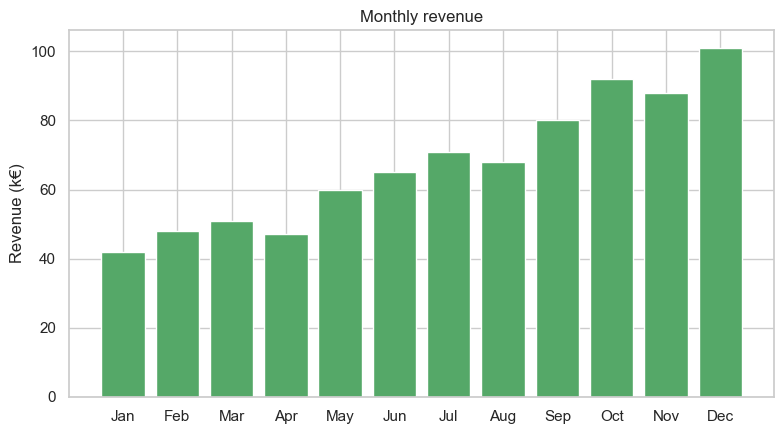

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(months, revenue_k, color='#55A868')
ax.set_ylabel("Revenue (k€)")
ax.set_title("Monthly revenue")
plt.tight_layout()
plt.show()


**How to read it:** each bar is one month's revenue; the upward drift from left to right is the growth the sparkline hinted at.

## 10. Nested lists — a small table

A list of lists is the simplest way to represent a small table — one inner list per row. It's perfectly fine for a handful of records; for anything bigger you'll switch to pandas in Notebook 6.

In [18]:
# columns: customer, mrr_eur, months_active, plan
customers = [
    ["Acme Inc.",      1_250,  18, "Premium"],
    ["Beta GmbH",        420,   7, "Standard"],
    ["Cygnus Ltd.",    5_800,  32, "Enterprise"],
    ["Delta Co.",        110,   3, "Free"],
    ["Epsilon AG",     2_900,  21, "Premium"],
]

# Header
print(f"{'Customer':<14}{'MRR (€)':>10}{'Months':>8}  {'Plan':<10}")
print("-" * 44)

# Walk the rows — tuple-style unpacking pulls each row apart
for row in customers:
    name, mrr, months, plan = row
    print(f"{name:<14}{mrr:>10,}{months:>8}  {plan:<10}")


Customer         MRR (€)  Months  Plan      
--------------------------------------------
Acme Inc.          1,250      18  Premium   
Beta GmbH            420       7  Standard  
Cygnus Ltd.        5,800      32  Enterprise
Delta Co.            110       3  Free      
Epsilon AG         2,900      21  Premium   


For any *real* tabular dataset, switch to pandas (Notebook 6). Nested lists are fine for tiny demos but quickly become awkward.

---

### ✋ Quick exercise (~2 min) — Query a tiny table

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Here is a small nested-list table where each row is `[name, mrr_eur, plan]`. Compute the **total MRR** across all customers, and build a **list of the names** on the `"Premium"` plan.

```python
rows = [
    ["Acme Inc.",   1_250, "Premium"],
    ["Beta GmbH",     420, "Standard"],
    ["Cygnus Ltd.", 5_800, "Enterprise"],
    ["Epsilon AG",  2_900, "Premium"],
]
```

In [ ]:
# ✍️ Your turn 👇
# each row is [name, mrr_eur, plan]
rows = [
    ["Acme Inc.",   1_250, "Premium"],
    ["Beta GmbH",     420, "Standard"],
    ["Cygnus Ltd.", 5_800, "Enterprise"],
    ["Epsilon AG",  2_900, "Premium"],
]

total_mrr = ...   # sum of every customer's MRR
premium   = ...   # list of names where plan == "Premium"
print(total_mrr, premium)

<details>
<summary>✅ <b>Solution</b></summary>

```python
total_mrr = sum([row[1] for row in rows])
premium   = [row[0] for row in rows if row[2] == "Premium"]
print(total_mrr, premium)
```

Each `row` is a small list, so `row[1]` reaches the MRR column and `row[2]` the plan column. One comprehension pulls a column to sum; the other filters rows by plan and keeps the name — exactly the per-column work pandas will later do for you.
</details>

## 11. Common pitfalls

| Pitfall                                  | Example                                | How to avoid |
|------------------------------------------|----------------------------------------|--------------|
| Off-by-one on slice end                  | `data[0:3]` ≠ first 3 items? It does — end is exclusive. | Remember: **stop is exclusive**. |
| Confusing `sort` and `sorted`            | `nums = nums.sort()` → `None`          | Use `sorted()` unless you must mutate in place. |
| Modifying a list while iterating         | `for x in lst: lst.remove(x)` skips items | Iterate over a **copy** (`for x in lst[:]`) or build a new list. |
| Two names pointing to the **same** list  | `b = a; b.append(1)` changes `a` too   | Copy with `a.copy()`, `list(a)`, or `a[:]`. |
| Treating tuples like lists               | `(1, 2)[0] = 99` → `TypeError`         | Tuples are *immutable* — rebuild instead. |

In [19]:
# The "same list under two names" trap — important to understand
a = [1, 2, 3]
b = a              # b refers to the SAME list, not a copy
b.append(99)

print(f"a = {a}")  # surprising? both changed!
print(f"b = {b}")

# A real copy:
a = [1, 2, 3]
b = a.copy()       # or list(a) or a[:]
b.append(99)

print(f"\nAfter explicit copy:")
print(f"a = {a}")
print(f"b = {b}")


a = [1, 2, 3, 99]
b = [1, 2, 3, 99]

After explicit copy:
a = [1, 2, 3]
b = [1, 2, 3, 99]


### 🔬 What actually happens — `b = a` does NOT copy the list

Assignment in Python **never copies** a list. `b = a` copies the *arrow*, not the box: both names point at the **one** list object in memory. So mutating through either name is visible through the other — that's the whole trap.

```text
   a ────┐
         ▼
      ┌───────────────┐
      │  list object  │   ← ONE list, in memory
      │  [1, 2, 3, 99]│
      └───────────────┘
         ▲
   b ────┘
```

**Step by step** for `a = [1, 2, 3]; b = a; b.append(99)`:

1. `a = [1, 2, 3]` builds one list object; `a` points at it.
2. `b = a` copies the **reference** — now `a` and `b` are two names for the **same** box.
3. `b.append(99)` mutates that one box *in place* — so `a` sees `[1, 2, 3, 99]` too.

The proof is identity: `a is b` is `True` and `id(a) == id(b)`. `is` / `id()` ask *"are these the very same object?"* — not *"do they look equal?"*.

In [20]:
# Proof: b = a makes TWO names for ONE list object
a = [1, 2, 3]
b = a                       # copies the reference, NOT the list

print("a is b   :", a is b)             # True  → same object
print("same id? :", id(a) == id(b))     # True  → same memory address

b.append(99)
print("a        :", a)                  # [1, 2, 3, 99]  ← a changed too!

# The fix: make a real (shallow) copy — any of these three works
a = [1, 2, 3]
b = a.copy()                # or list(a)  or  a[:]
print("\nafter copy → a is b:", a is b) # False → different objects now
b.append(99)
print("a        :", a)                  # [1, 2, 3]    ← untouched
print("b        :", b)                  # [1, 2, 3, 99]

a is b   : True
same id? : True
a        : [1, 2, 3, 99]

after copy → a is b: False
a        : [1, 2, 3]
b        : [1, 2, 3, 99]


> 🎯 **Read `=` as "label this object", not "copy it".** Variables are name tags you stick on objects, not boxes that hold values. `b = a` sticks a second tag on the same list.

> ⚠️ **Shallow copy isn't enough for NESTED data.** `a.copy()`, `a[:]`, and `list(a)` copy the *outer* list but still **share the inner objects**. Mutate an inner list and both copies see it. For nested lists/dicts use `copy.deepcopy` to clone all the way down.

In [21]:
import copy

# A NESTED list — a shallow copy shares the inner lists
grid    = [[1, 2], [3, 4]]
shallow = grid.copy()           # outer copied, inner lists SHARED
deep    = copy.deepcopy(grid)   # everything cloned, top to bottom

grid[0].append(99)              # mutate an INNER list

print("grid    :", grid)        # [[1, 2, 99], [3, 4]]
print("shallow :", shallow)     # [[1, 2, 99], [3, 4]]  ← leaked! inner list shared
print("deep    :", deep)        # [[1, 2],     [3, 4]]  ← safe, fully independent

# 🧠 Rule: shallow copy for flat lists; copy.deepcopy for nested lists/dicts.

grid    : [[1, 2, 99], [3, 4]]
shallow : [[1, 2, 99], [3, 4]]
deep    : [[1, 2], [3, 4]]


## 🔑 Dictionaries — a 2-minute primer

Here's the second shape from our mental model: the **labelled drawer**. Lists hold items *in order*; a **dictionary** holds **key → value** pairs you look up *by name*. When your data isn't "item 0, item 1, item 2" but "the price *of* gpt-4o-mini", reach for a dict. They're everywhere in AI work — JSON, API responses, and LLM chat messages all arrive as dicts — and you'll need them in the exercises below and throughout the rest of the fast track.

- `d[key]` looks a value up by key; `d.get(key, default)` does it *safely* (no crash on a missing key).
- `d[key] = value` adds or updates a key.
- `for k, v in d.items():` iterates keys and values together.
- **Counting** is the most common pattern: `collections.Counter(items)`, or by hand `counts[k] = counts.get(k, 0) + 1`.

> 💡 The full course gives dictionaries an entire notebook ([`01_foundations/04_dictionaries_advanced.ipynb`](../01_foundations/04_dictionaries_advanced.ipynb)); this primer is the slice you need for the fast track.

> 🚫 **Misconception — "`key in my_dict` checks the values."**
> For a dict, `in` tests the **keys**, not the values: `"Alice" in {"Alice": 30}` is `True`, but `30 in {"Alice": 30}` is `False`. To search values use `30 in my_dict.values()`. And to read a key that might be missing without crashing, prefer `my_dict.get(key, default)` over `my_dict[key]` (which raises `KeyError`).

In [22]:
prices = {"gpt-4o-mini": 0.0006, "claude-haiku": 0.0008}
print(prices["gpt-4o-mini"])        # look up a value by its key
print(prices.get("unknown-model", 0.0))  # safe lookup — key missing, so you get the 0.0 default
prices["new-model"] = 0.0012        # add / update a key

for name, price in prices.items():  # iterate keys AND values together
    print(name, price)

from collections import Counter
tickets = ["billing", "tech", "billing", "feature", "billing"]
print(Counter(tickets))             # Counter({'billing': 3, 'tech': 1, 'feature': 1})

0.0006
0.0
gpt-4o-mini 0.0006
claude-haiku 0.0008
new-model 0.0012
Counter({'billing': 3, 'tech': 1, 'feature': 1})


## 🧪 Practice exercises

### Exercise 1 — ⭐ Filter expensive calls

Given a list of token counts per call, build a new list of the **calls that cost more than $0.001** at a price of `$0.0009 per 1K tokens`. Do it **two ways**: (a) a `for` loop, (b) a list comprehension.

In [23]:
tokens_per_call = [320, 1450, 880, 2100, 540, 1190, 670, 2050, 410]
price_per_1k    = 0.0009

# Method 1: loop
expensive_loop = []
# ...

# Method 2: comprehension
expensive_comp = []


<details>
<summary>💡 <b>Solution</b></summary>

```python
tokens_per_call = [320, 1450, 880, 2100, 540, 1190, 670, 2050, 410]
price_per_1k    = 0.0009

# Method 1
expensive_loop = []
for t in tokens_per_call:
    cost = t / 1000 * price_per_1k
    if cost > 0.001:
        expensive_loop.append(t)

# Method 2
expensive_comp = [
    t for t in tokens_per_call
    if t / 1000 * price_per_1k > 0.001
]

print("loop          :", expensive_loop)
print("comprehension :", expensive_comp)
```

Both return the same list. For a one-line filter, the comprehension is the idiomatic choice.
</details>

### Exercise 2 — ⭐⭐ Slicing practice

Given `X = [10, 20, …, 100]`, predict (without running!) what each of these returns, then check.

```python
X[0:3]
X[-3:]
X[::2]
X[1::2]
X[:-1]
X[::-1]
```

In [24]:
X = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

print("X[0:3]  =", X[0:3])
print("X[-3:]  =", X[-3:])
print("X[::2]  =", X[::2])
print("X[1::2] =", X[1::2])
print("X[:-1]  =", X[:-1])
print("X[::-1] =", X[::-1])


X[0:3]  = [10, 20, 30]
X[-3:]  = [80, 90, 100]
X[::2]  = [10, 30, 50, 70, 90]
X[1::2] = [20, 40, 60, 80, 100]
X[:-1]  = [10, 20, 30, 40, 50, 60, 70, 80, 90]
X[::-1] = [100, 90, 80, 70, 60, 50, 40, 30, 20, 10]


<details>
<summary>💡 <b>Solution & explanation</b></summary>

| Expression | Result | Why |
|---|---|---|
| `X[0:3]`  | `[10, 20, 30]`            | first 3, stop exclusive |
| `X[-3:]`  | `[80, 90, 100]`           | last 3 |
| `X[::2]`  | `[10, 30, 50, 70, 90]`    | every other, from start |
| `X[1::2]` | `[20, 40, 60, 80, 100]`   | every other, from index 1 |
| `X[:-1]`  | `[10, 20, …, 90]`         | everything but the last |
| `X[::-1]` | `[100, 90, …, 10]`        | reversed (step = -1) |

Once these six shapes are reflexive, slicing in NumPy and pandas will feel obvious.
</details>

### Exercise 3 — ⭐⭐ Monthly revenue analysis

Analyse the monthly revenue below:

1. Compute **total** annual revenue and the **average** monthly revenue.
2. Find the **best** and **worst** months (use both the value *and* the month name).
3. List all months where revenue was **above average**.

In [25]:
revenue = [125_000, 132_000, 118_000, 145_000, 139_000, 152_000,
           148_000, 136_000, 129_000, 141_000, 155_000, 162_000]
months  = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
           "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
total = sum(revenue)
avg   = total / len(revenue)

print(f"Total annual revenue : €{total:,}")
print(f"Average per month    : €{avg:,.0f}")

best_idx  = revenue.index(max(revenue))
worst_idx = revenue.index(min(revenue))
print(f"Best month  : {months[best_idx]}  (€{revenue[best_idx]:,})")
print(f"Worst month : {months[worst_idx]}  (€{revenue[worst_idx]:,})")

above = [m for m, r in zip(months, revenue) if r > avg]
print(f"Months above average: {above}")
```

**New trick used:** `zip(months, revenue)` pairs the two lists element-by-element so you can iterate over both at once. This pattern is *everywhere* in data work — and exactly what pandas does for you in one line once columns sit in a DataFrame.
</details>

### Exercise 4 — ⭐⭐ Customer-record transformation

Each row of `customers` is `[name, mrr_eur, months_active, plan]`. Compute:

1. The total MRR across all customers.
2. The **average months active** for customers on the `"Premium"` plan only.
3. A new list with **one entry per customer**: `"keep"` if MRR ≥ 1000 and months_active ≥ 12, `"watch"` if MRR ≥ 1000 and months_active < 12, `"upsell"` otherwise.

In [26]:
customers = [
    ["Acme Inc.",      1_250,  18, "Premium"],
    ["Beta GmbH",        420,   7, "Standard"],
    ["Cygnus Ltd.",    5_800,  32, "Enterprise"],
    ["Delta Co.",        110,   3, "Free"],
    ["Epsilon AG",     2_900,  21, "Premium"],
    ["Zeta SE",        1_100,   4, "Premium"],
]

# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
# 1. Total MRR
total_mrr = sum(row[1] for row in customers)
print(f"Total MRR: €{total_mrr:,}")

# 2. Average months active for Premium customers only
premium_months = [row[2] for row in customers if row[3] == "Premium"]
print(f"Avg months active (Premium): {sum(premium_months)/len(premium_months):.1f}")

# 3. Categorise each customer
def status(mrr, months):
    if mrr >= 1000 and months >= 12: return "keep"
    if mrr >= 1000:                  return "watch"
    return "upsell"

labels = [status(row[1], row[2]) for row in customers]

for row, lab in zip(customers, labels):
    print(f"  {row[0]:<14} → {lab}")
```

**Patterns used:**

- `sum(... for row in ...)` — a *generator expression*, super-handy for "sum / count by formula".
- list comprehension with a filter to pull one column.
- helper function for clear classification rules — much more readable than three nested ternaries.
</details>

### Exercise 5 — ⭐⭐ Debug me 🐞

The function below is supposed to return a list of **all even numbers** in `nums`, but it keeps returning the wrong thing. Fix it.

In [27]:
# 👇 Your fixed/corrected version goes here — write or paste it below.
def evens(nums):
    result = []
    for n in nums:
        if n % 2 == 0:
            result = n        # ← something is wrong here
    return result

print(evens([1, 2, 3, 4, 5, 6]))


6


<details>
<summary>💡 <b>Solution</b></summary>

The bug is `result = n` — that **replaces** `result` with the current number instead of *appending* to it. Fix:

```python
def evens(nums):
    result = []
    for n in nums:
        if n % 2 == 0:
            result.append(n)        # ← was: result = n
    return result

print(evens([1, 2, 3, 4, 5, 6]))   # → [2, 4, 6]
```

Or shorter, with a comprehension:

```python
def evens(nums):
    return [n for n in nums if n % 2 == 0]
```

This is *the* most common beginner bug with the accumulator pattern. Whenever you build a list, mentally check: am I `.append`-ing, or am I overwriting?
</details>

## 🧠 Stretch exercises

Two more applied exercises to deepen the material. Try them yourself before opening the solution.


### Stretch exercise C — ⭐⭐⭐ Deduplicate while preserving order

`set()` removes duplicates but **loses order**. Write a function `dedup(items)` that keeps only the **first** occurrence of each item and preserves the original order.

```python
dedup(["a", "b", "a", "c", "b", "d"])  # → ['a', 'b', 'c', 'd']
```

In [28]:
# Your code here  👇
def dedup(items):
    ...

print(dedup(["a", "b", "a", "c", "b", "d"]))


None


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def dedup(items):
    seen = set()
    out  = []
    for x in items:
        if x not in seen:
            seen.add(x)
            out.append(x)
    return out
```

**Reasoning.** This is the canonical "set as a fast membership probe, list as the ordered result" pattern. `x not in seen` is **O(1)** because `seen` is a set, so the whole function is O(n) — much faster than the naive `if x not in out:` against a list, which is O(n²). On Python 3.7+ you can also write `list(dict.fromkeys(items))` as a one-liner — dicts preserve insertion order, so this is a neat trick to know for quick scripts.
</details>

### Stretch exercise D — ⭐⭐⭐ Sliding window maximum

Given a list of numbers and a window size `k`, return a list of the **maximum value in each sliding window of size k**.

```python
sliding_max([1, 3, -1, -3, 5, 3, 6, 7], k=3)  # → [3, 3, 5, 5, 6, 7]
```

Aim for a clean O(n·k) version first — clarity beats cleverness. (There is an O(n) algorithm with `collections.deque` if you want to come back to this after the next notebook.)

In [29]:
# Your code here  👇
def sliding_max(values, k):
    ...

print(sliding_max([1, 3, -1, -3, 5, 3, 6, 7], k=3))


None


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def sliding_max(values, k):
    return [max(values[i:i+k]) for i in range(len(values) - k + 1)]
```

**Reasoning.** Slicing `values[i:i+k]` and calling `max()` on each window keeps the code obvious and one-line. The number of windows is `n - k + 1`, which is where the slightly fiddly `range(len(values) - k + 1)` comes from — off-by-one errors here are a classic interview trap, so verify by hand on the example: `len = 8, k = 3` → `8 - 3 + 1 = 6` windows, which matches the expected output. The O(n) variant with a monotonic deque is a great follow-up if you ever bump into this on very long sequences.
</details>

## 🧠 Key takeaways

1. Lists are **ordered, mutable** collections; indexing starts at 0 and supports negatives.
2. **Slicing** `[start:stop:step]` is the syntax you'll use most: stop is exclusive, any field is optional.
3. The accumulator pattern (`result = []` → `result.append(...)`) is everywhere.
4. **List comprehensions** are the Pythonic way to filter / transform: `[f(x) for x in xs if cond]`.
5. **Tuples** are immutable lists — use them for fixed-size records (coordinates, rows, API endpoints).
6. **Strings are sequences too** — indexing, slicing, splitting all work on them.
7. **`zip()` walks parallel lists**; `enumerate()` adds an index. (Sorting by any field with `key=lambda ...` arrives in NB 4.)
8. Watch out for *aliasing* (`b = a` shares the same list) — use `.copy()` for a real duplicate.
9. The two shapes to keep: a **list is a row of numbered boxes** (reach in by position), a **dict is a labelled drawer** (reach in by name). Picking the right one is half of clean data code.

## ✅ Self-assessment

- [ ] Use positive and negative indexing
- [ ] Predict and write slices including step
- [ ] Use `append`, `extend`, `insert`, `remove`, `pop`
- [ ] Write a list comprehension with both transform and filter
- [ ] Iterate with `enumerate` and `zip`
- [ ] Explain when to use a tuple instead of a list

## 🚀 Next step

Continue with **Notebook 4 (fast track) — Functions and Modules**, where you'll package the snippets you've been writing into reusable, named building blocks — the foundation of every clean script.